# 🧩 Premium AutoClustering Engine — Syntax Guide & Protocol

This notebook provides a structured playground for testing and configuring the `AutoMLFactory` for unsupervised clustering and segmentation workloads.

> **Important**: Ensure your dataset is pre-cleaned. Unsupervised learning requires normalized numeric columns for geometric distance calculations.

---

## 📜 The Configuration Schema

The `AUTOML_CONFIG` dictionary defines the engine's behavior. Below are the keys strictly related to `task_type = "clustering"`.

| Key | Type | Description | Available Options | Example |
|:---|:---|:---|:---|:---|
| `experiment_name` | `str` | MLflow experiment identifier. | Any string | `"Customer_Segmentation"` |
| `task_type` | `str` | ML task routing. | `"clustering"` | `"clustering"` |
| `dataset_path` | `str` | Path to cleaned historical training CSV data. | Any valid path | `"dummy_dataset/customer_data.csv"` |
| `features` | `List[str]` | Explicit columns for clustering; empty list uses all numeric columns. | List of column names, `[]` | `[]` |
| `exclude_features` | `List[str]` | Columns to explicitly ignore or exclude from clustering. | List of column names, `[]` | `["customer_id"]` |
| `n_clusters` | `int` | Fixed number of clusters (K). `None` enables Auto-K sweep. | Any positive integer, `None` | `None` |
| `clustering_max_k` | `int` | Upper bound for Auto-K optimization sweeps. | Any positive integer | `10` |
| `clustering_algorithms` | `List[str]` | List of candidate clustering algorithms to evaluate. | `"kmeans"`, `"mbkmeans"`, `"dbscan"`, `"hdbscan"`, `"agglomerative"`, `"spectral"` | `["mbkmeans", "hdbscan", "agglomerative"]` |
| `clustering_reduction_method` | `str` | Dimension reduction method prior to clustering. | `"pca"`, `"umap"`, `"auto"` | `"auto"` |
| `clustering_tune_trials` | `int`, `None` | Number of Optuna trials to run. `None` disables tuning. | Any positive integer, `None` | `None` |
| `base_output_dir` | `str` | Directory for models, plots, and predictions. | Any valid directory path | `"automl_clustering_run"` |
| `prediction_data_path` | `str` | Path to unseen prediction data for batch inference. | Any valid path, `None` | `"dummy_dataset/new_leads.csv"` |
| `fast_dev_run` | `bool` | Quick prototyping mode (subsamples data). | `True`, `False` | `False` |
| `ai_context` | `str` | Business context string to guide the AI natural language report summary. | Any string, `None` | `"Grouping customer purchase behaviors to identify high-value cohorts."` |

### 🛡️ Production-Grade Hardening Patches Active
1. **Scalability Guard (Data Size Router)**: If the dataset size exceeds $30,000$ rows, heavy memory-bound algorithms (HDBSCAN, Agglomerative) are auto-bypassed in favor of `MiniBatchKMeans` to ensure zero OOM or system segment crashes.
2. **Parallel PCA Evaluation Space**: Non-linear UMAP projections distort metric distances. To ensure mathematical precision, internal validation scores (Silhouette, DBI, CHI) are evaluated on a linear parallel PCA metric space, keeping UMAP coordinates strictly for breathtaking 2D projections.
3. **Anomaly & Noise Group Isolation**: Outlier/noise rows (labeled `-1` by density algorithms) are isolated from surrogate explanation models to prevent XAI driver corruption, and profiled separately.
4. **Resilient Feature Cleaning**: Numerical features are filtered through an automated variance filter ($var > 10^{-5}$) and a correlation redundancy filter ($|r| \le 0.95$), with an auto-revert fallback mechanism.
| `exclude_features` | `List[str]` | Columns to explicitly ignore or exclude from clustering. | List of column names, `[]` | `["customer_id"]` |

### 🚫 Strict Rules
1. **Prerequisite**: Data must be cleaned and numeric/categorical features encoded before ingestion.
| `exclude_features` | `List[str]` | Columns to explicitly ignore or exclude from clustering. | List of column names, `[]` | `["customer_id"]` |
2. **Unseen Predictions**: Unseen prediction data passed to `prediction_data_path` must match the exact schema of training data.
3. **Seed Control**: Ensure `random_state` is set to ensure reproducibility of clustering models and PCA/UMAP layouts.

### 📋 Blank Configuration Template

Copy this block and customize for your dataset:

```python
AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "Clustering_Run",
    "task_type": "clustering",
    "dataset_path": "Dataset/your_file.csv",
    "features": [],                         # Empty [] defaults to using all numeric columns
    "exclude_features": [],                 # Columns to explicitly ignore

    # ── Clustering Parameters & Algorithms ──────────────────────────
    "n_clusters": None,                     # Fixed K, or None for Auto-K sweep
    "clustering_max_k": 10,                 # Sweep upper bound
    "clustering_algorithms": ["mbkmeans", "hdbscan", "agglomerative"],
    "clustering_reduction_method": "auto",  # auto, pca, umap
    "clustering_tune_trials": None,         # Number of trials for Optuna. None disables tuning.

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_clustering_run",
    "prediction_data_path": None,           # Optional path to inference CSV
    "fast_dev_run": False,

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Grouping customer purchase behaviors to identify high-value cohorts."
}
```


---
## ⚙️ Step 1: Pipeline Configuration
Customize the dictionary below for your dataset and experiment.

In [1]:
# ══════════════════════════════════════════════════════════════════════
#  Pipeline Configuration
# ══════════════════════════════════════════════════════════════════════

AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "Customer_Segmentation_Run",
    "task_type": "clustering",
    "dataset_path": "dummy_dataset/customer_data.csv",
    "features": [],                         # Empty [] defaults to using all numeric columns
    "exclude_features": ["customer_id"],    # Columns to explicitly ignore

    # ── Clustering Parameters & Algorithms ──────────────────────────
    "n_clusters": None,                     # Fixed K, or None for Auto-K sweep
    "clustering_max_k": 10,                 # Sweep upper bound
    "clustering_algorithms": ["kmeans", "mbkmeans", "dbscan", "hdbscan", "agglomerative", "spectral"],
    "clustering_reduction_method": "auto",  # auto, pca, umap
    "clustering_tune_trials": 20,           # Set a positive integer to enable tuning, or None to disable

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_clustering_run",
    "prediction_data_path": "dummy_dataset/customer_data.csv",
    "fast_dev_run": False,

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Grouping customer purchase behaviors to identify high-value cohorts."
}


---
## 🚀 Step 2: Execute Engine
This orchestrates data loading, universal scaling/encoding, variance/correlation filtering, dimensional reduction, algorithm sweep/auto-K optimization, surrogate explainers, and logging. The premium HTML dashboard will render automatically upon completion.

Rank,Feature,Importance,Bar
1,annual_income,0.2597,
2,spending_score,0.2498,
3,purchase_frequency,0.1761,
4,age,0.1030,
5,tenure_months,0.0698,
6,last_purchase_days_ago,0.0682,
7,membership_tier: Bronze,0.0346,
8,membership_tier: Platinum,0.0128,
9,membership_tier: Silver,0.0078,
10,membership_tier: Gold,0.0059,

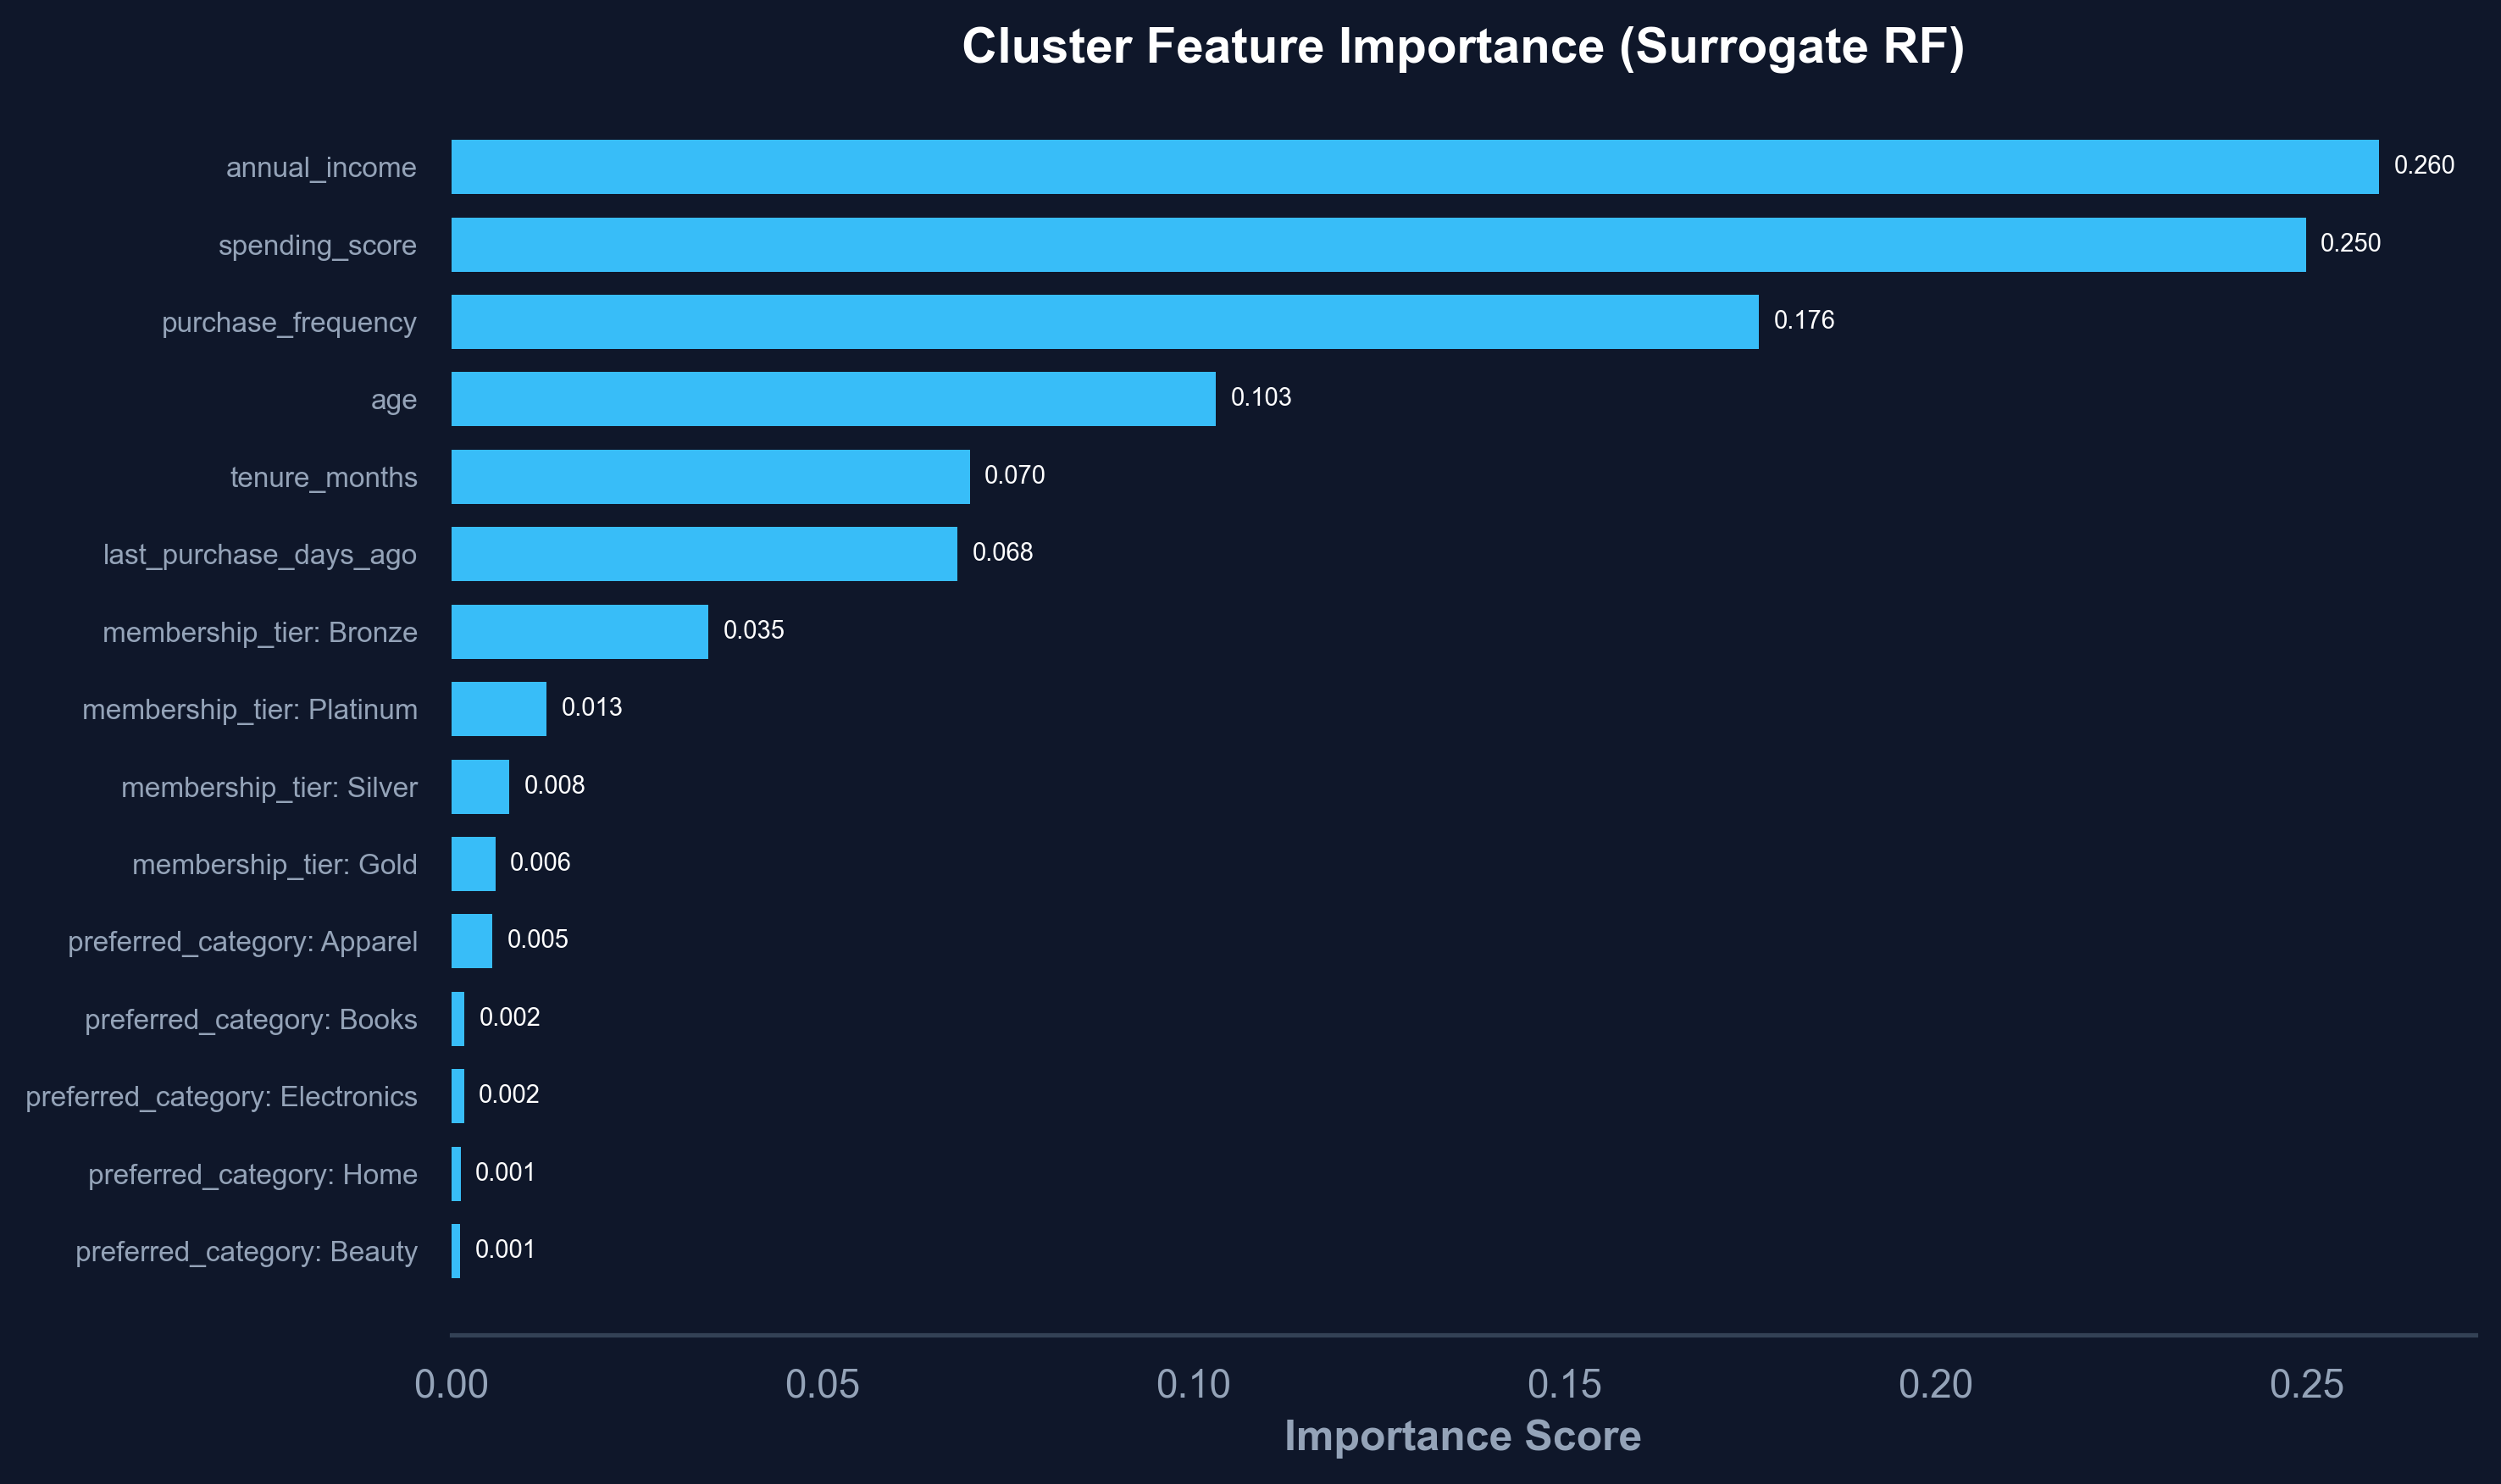
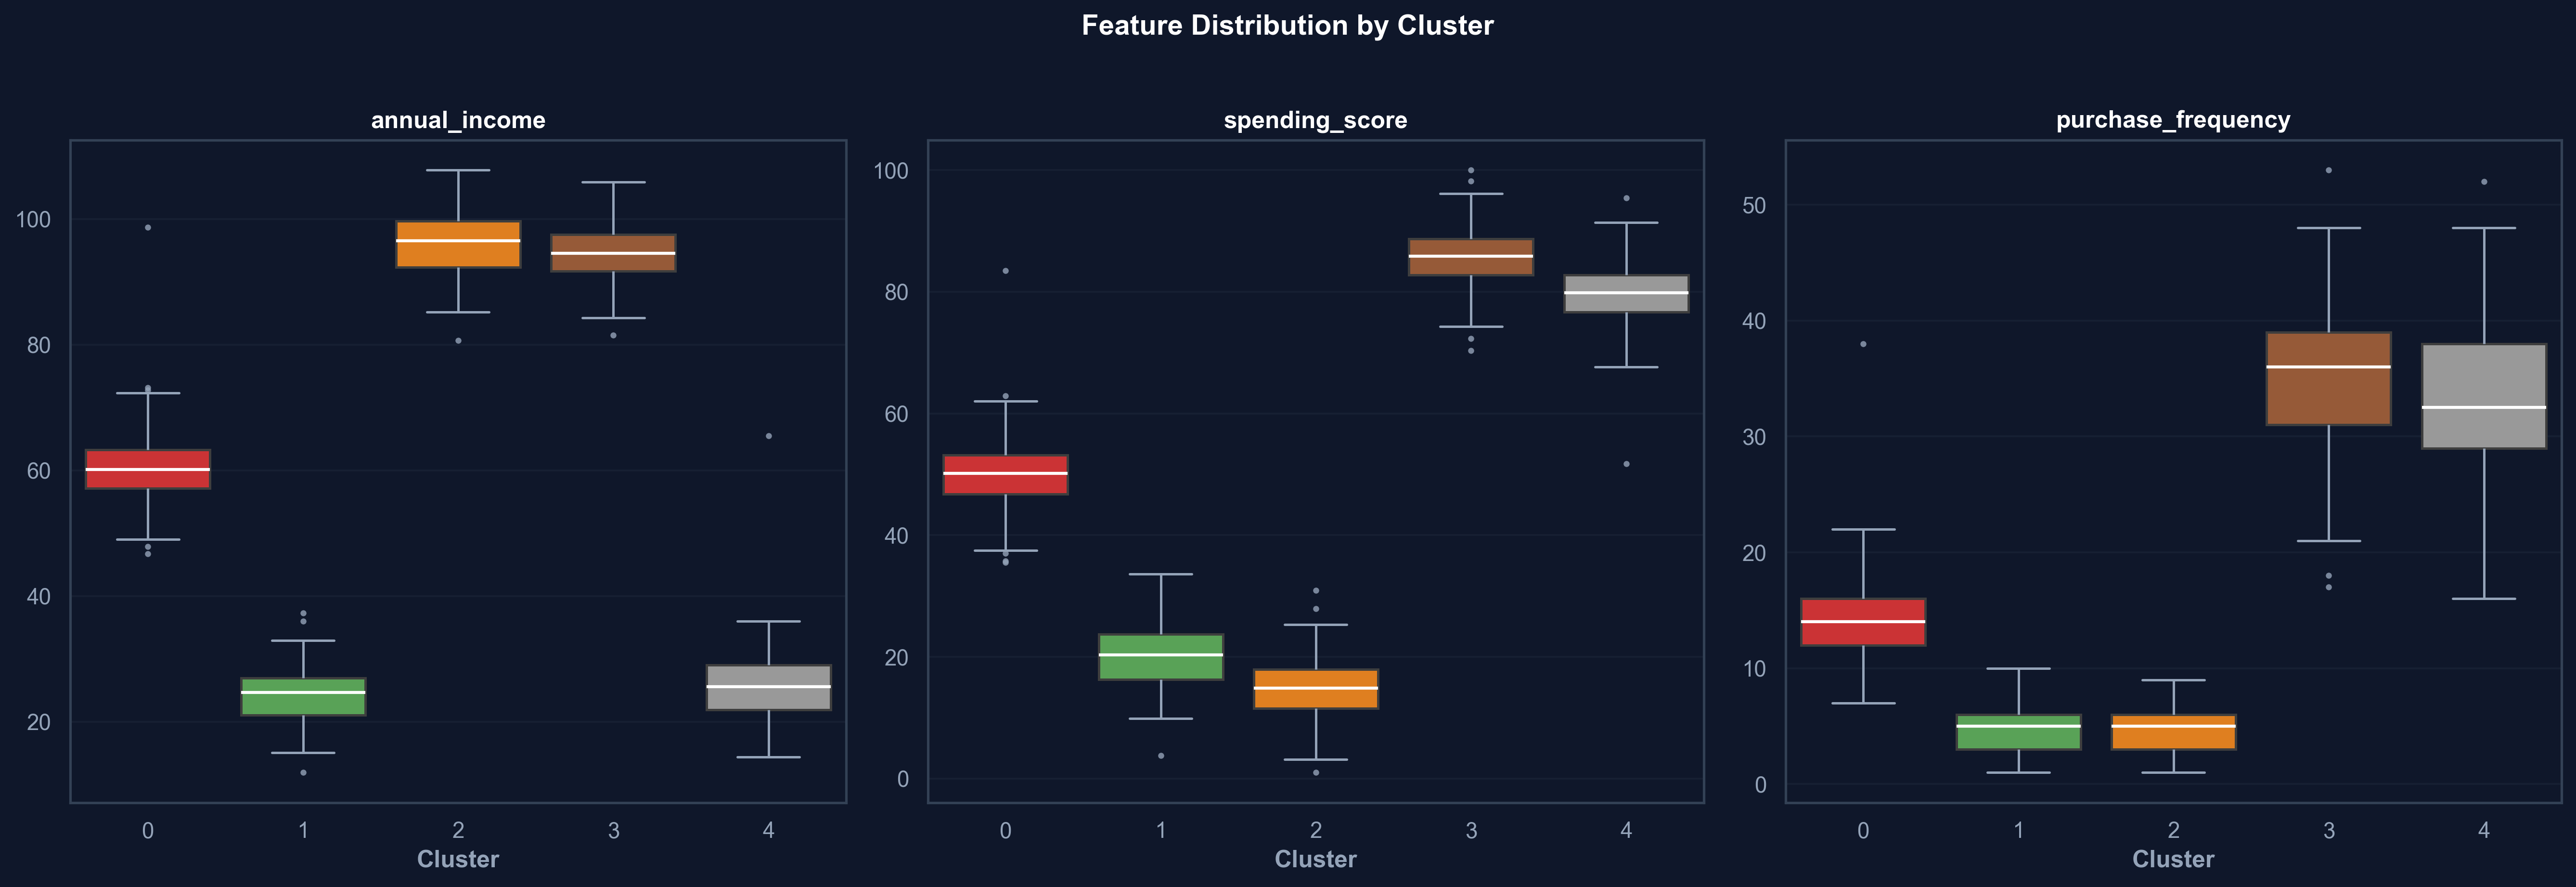
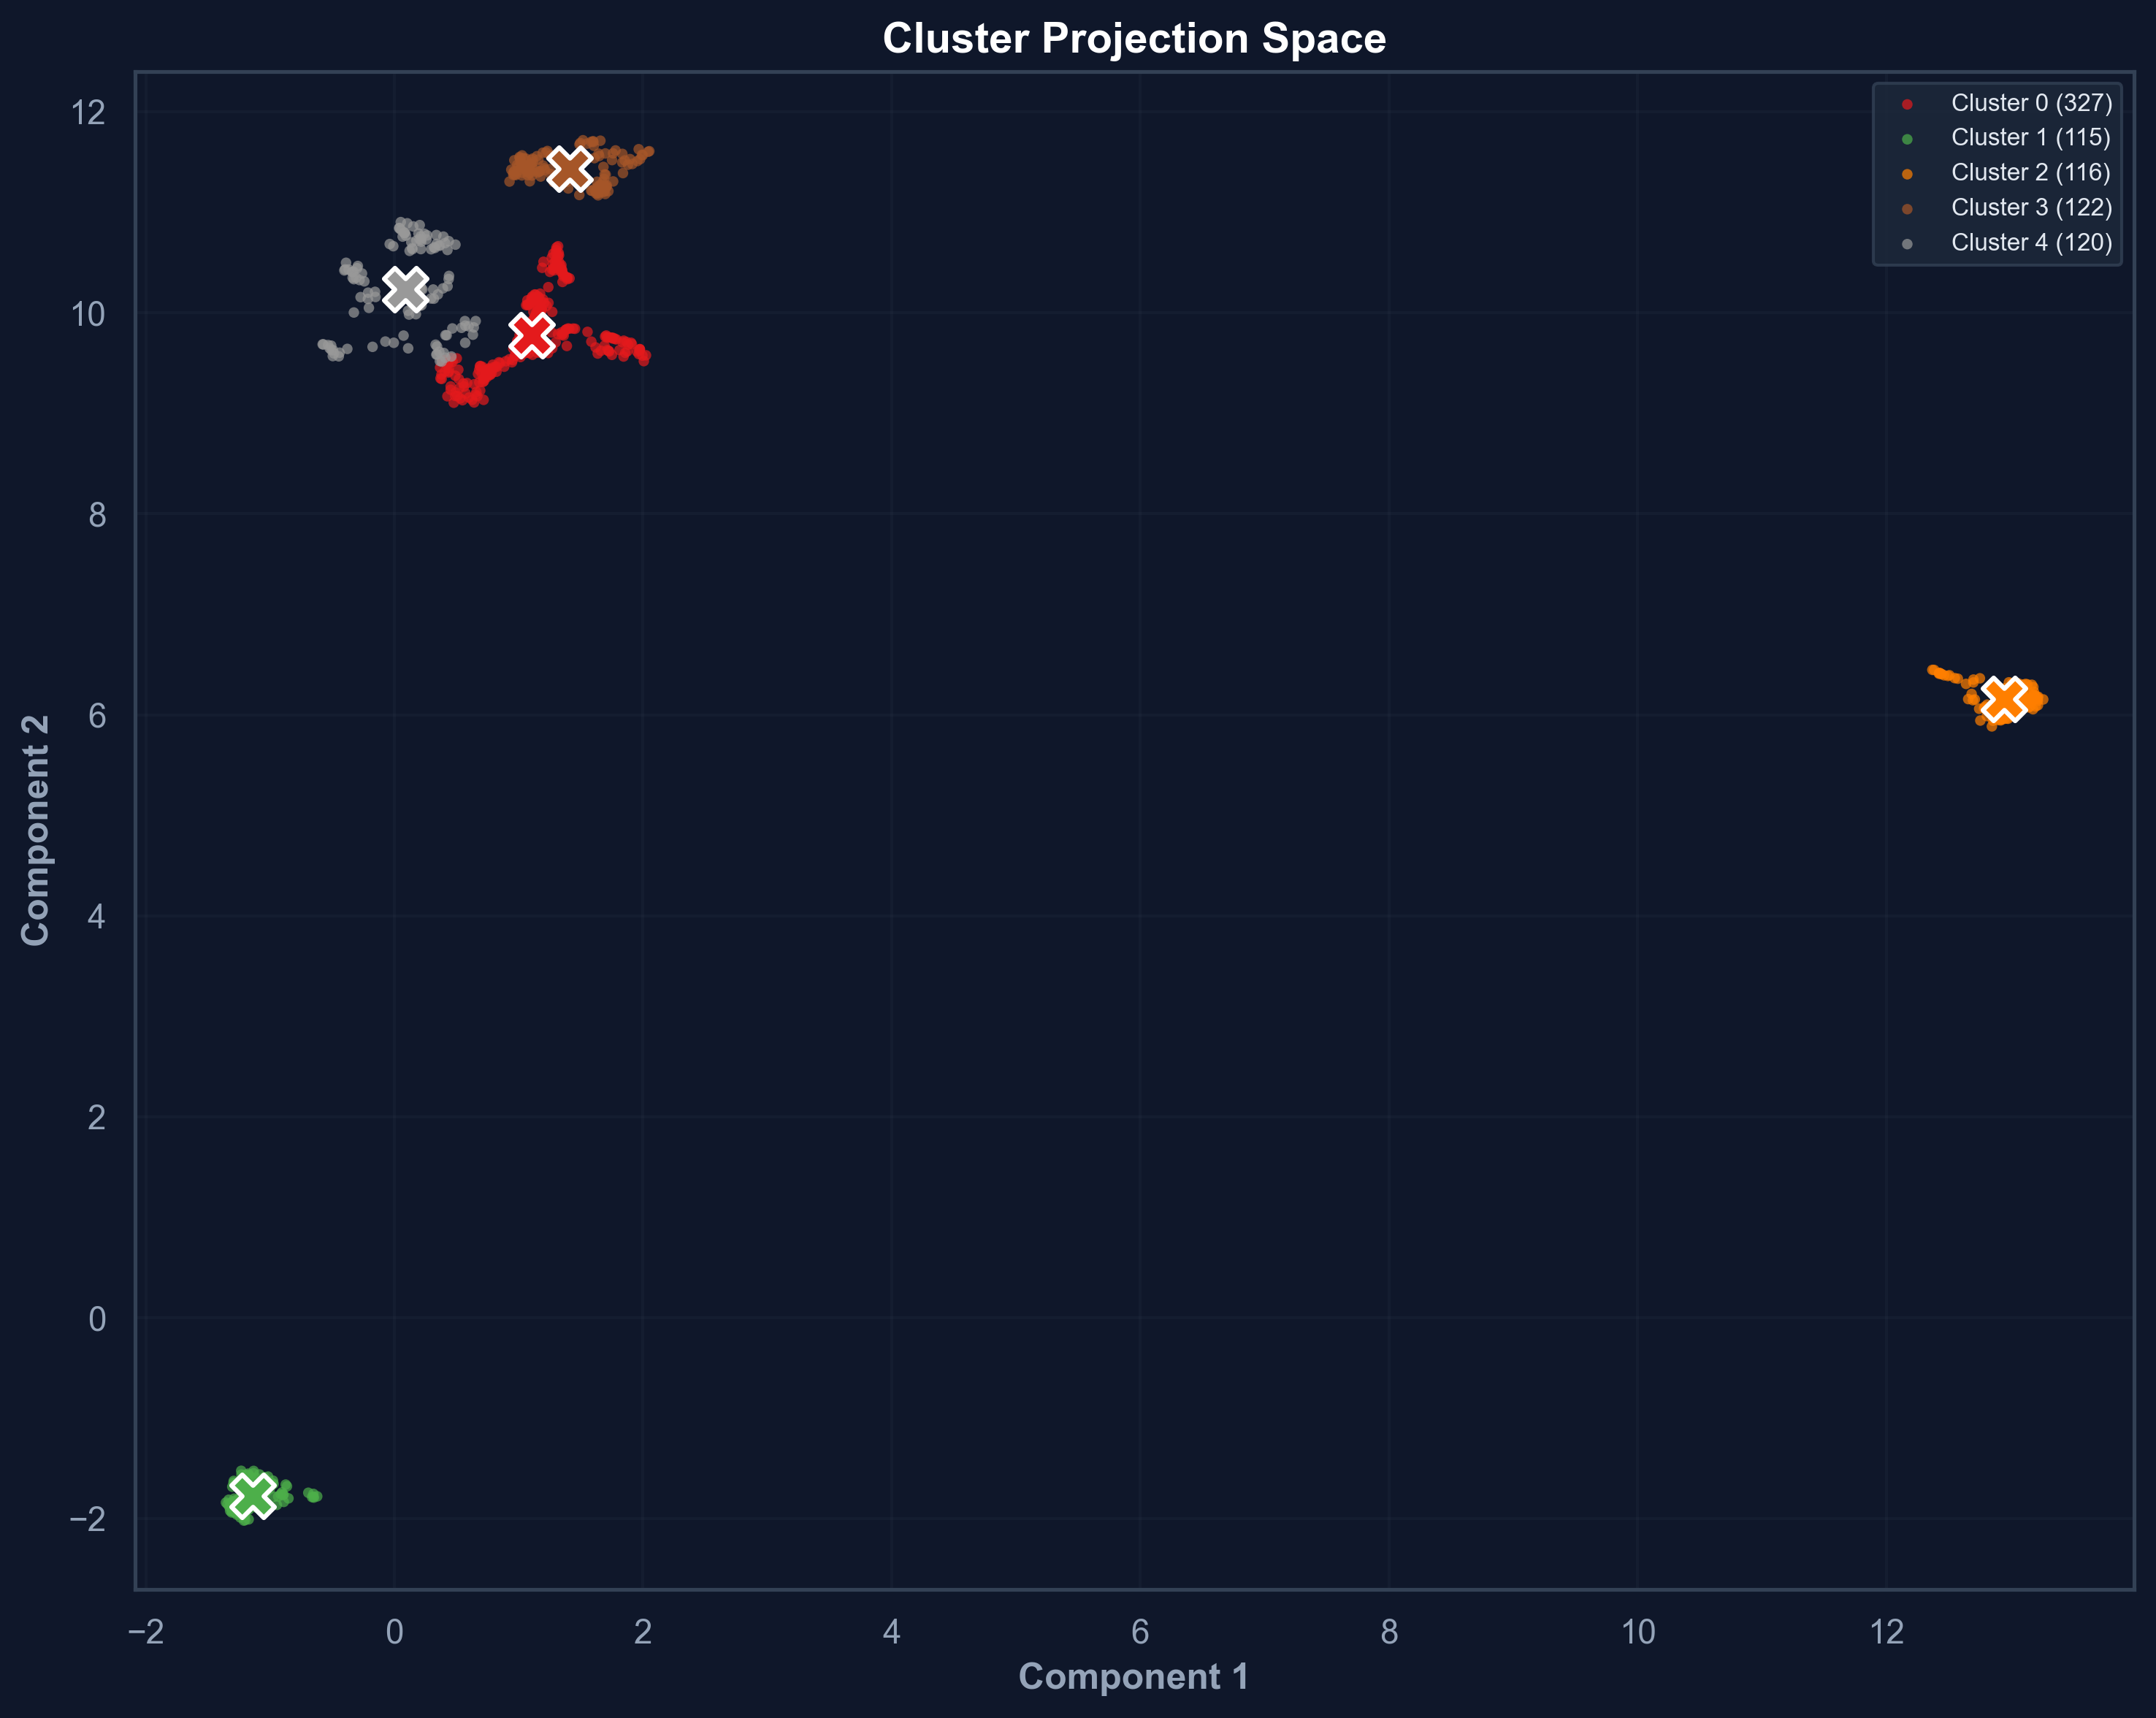

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  Execution
# ══════════════════════════════════════════════════════════════════════

from ml_engine import AutoMLFactory

factory = AutoMLFactory(AUTOML_CONFIG)
factory.execute_pipeline()

---
## 🔮 Step 3: Batch Inference (Optional)
If `prediction_data_path` is defined in the config, you can run batch prediction / segment assignment. Results are exported to `{base_output_dir}/predictions/batch_results.csv`.

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  Batch Inference
# ══════════════════════════════════════════════════════════════════════

# if AUTOML_CONFIG.get("prediction_data_path"):
#     factory.predict_and_export()